In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler 
class_survey_df = pd.read_csv("CSCINZ_Spring_2025_survey.csv")
class_survey_df.head()

,Timestamp,What is your name?,What are your pronouns?,What state/country were you born in?,How many siblings do you have?,How much experience do you have programming?,What class are you in?,Are you working while in school?,How many pets and of which kind do you have?,What is your favorite type of food?,Where do you live?,Do you take the metro?,What is your major?,How old are you?,What is your favorite TV show?,What is your favorite video game?,What is your favorite book?,Why are you taking this class?,Whats your favorite bash command?
0,2024/09/05 5:10:09 PM CST,Alejandro (Alex) Gonzalez,He/Him,Mexico,1,1-2 years,Freshman,No,"1, Dog",Japanese,Off campus,No,Computer Science,18,Friends,Persona Series,Anything about mythology,My major,cd and ls
1,2024/09/05 5:33:51 PM CST,Tanmay,He/Him,Missouri,1,0-3 months,Freshman,No,0,Mexican,On campus,No,CS/Business,18,Suits,Super Smash bros,Percy Jackson,To get a deeper understanding and basics of cs,ls
2,2024/09/05 5:34:21 PM CST,Akshay,She/Her,"Frankfurt, Germany",1,0-3 months,Freshman,No,no pets!,Italian,On campus,No,Data Science,18,How I Met Your Mother,Mario Kart,Harry Potter,To learn programming for my major!,git commit
3,2024/09/05 5:35:03 PM CST,Anthony,He/Him,Wisconsin,1,0-3 months,Senior,Yes,I have two dogs and they are both at home,Italian,Off campus,No,Business Economics,21,Breaking Bad,Call of Duty,NaN,Programming has always been an interest of mine,ls
4,2024/09/05 5:35:56 PM CST,Nuri,He/Him,"st. louis, mo",2,1-2 years,Freshman,No,0,American,On campus,No,computer science,18,Hunter x Hunter,valorant,berserk,interested in having a career in data,ls


In [71]:
class_survey_df['country'] = np.where(class_survey_df['What state/country were you born in?'] == 'Ethiopia', 'Ethiopia',
                                    np.where(class_survey_df['What state/country were you born in?'] == 'Nigeria', 'Nigeria',
                                             np.where(class_survey_df['What state/country were you born in?'] == 'Turkey', 'Turkey', 'Other')))
class_survey_df.head()

,Timestamp,What is your name?,What are your pronouns?,What state/country were you born in?,How many siblings do you have?,How much experience do you have programming?,What class are you in?,Are you working while in school?,How many pets and of which kind do you have?,What is your favorite type of food?,Where do you live?,Do you take the metro?,What is your major?,How old are you?,What is your favorite TV show?,What is your favorite video game?,What is your favorite book?,Why are you taking this class?,Whats your favorite bash command?,country
0,2024/09/05 5:10:09 PM CST,Alejandro (Alex) Gonzalez,He/Him,Mexico,1,1-2 years,Freshman,No,"1, Dog",Japanese,Off campus,No,Computer Science,18,Friends,Persona Series,Anything about mythology,My major,cd and ls,Other
1,2024/09/05 5:33:51 PM CST,Tanmay,He/Him,Missouri,1,0-3 months,Freshman,No,0,Mexican,On campus,No,CS/Business,18,Suits,Super Smash bros,Percy Jackson,To get a deeper understanding and basics of cs,ls,Other
2,2024/09/05 5:34:21 PM CST,Akshay,She/Her,"Frankfurt, Germany",1,0-3 months,Freshman,No,no pets!,Italian,On campus,No,Data Science,18,How I Met Your Mother,Mario Kart,Harry Potter,To learn programming for my major!,git commit,Other
3,2024/09/05 5:35:03 PM CST,Anthony,He/Him,Wisconsin,1,0-3 months,Senior,Yes,I have two dogs and they are both at home,Italian,Off campus,No,Business Economics,21,Breaking Bad,Call of Duty,NaN,Programming has always been an interest of mine,ls,Other
4,2024/09/05 5:35:56 PM CST,Nuri,He/Him,"st. louis, mo",2,1-2 years,Freshman,No,0,American,On campus,No,computer science,18,Hunter x Hunter,valorant,berserk,interested in having a career in data,ls,Other


In [76]:
class_survey_df = class_survey_df.dropna(subset=['How many pets and of which kind do you have?'])
class_survey_df['How many pets and of which kind do you have?'].str.contains('none', '0')
class_survey_df['Dogs'] = np.where(class_survey_df['How many pets and of which kind do you have?'].str.contains('dog'), '1','0')
class_survey_df['Cats'] = np.where(class_survey_df['How many pets and of which kind do you have?'].str.contains('cat'), '1','0')
class_survey_df['Other_pets'] = np.where(class_survey_df['How many pets and of which kind do you have?'].str.contains('tutle'), '1','0')
class_survey_df.head()

/var/folders/tz/zcz13sfd1jj_3jyf30pyc3pc0000gn/T/ipykernel_5976/3664327958.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  class_survey_df['Dogs'] = np.where(class_survey_df['How many pets and of which kind do you have?'].str.contains('dog'), '1','0')
/var/folders/tz/zcz13sfd1jj_3jyf30pyc3pc0000gn/T/ipykernel_5976/3664327958.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  class_survey_df['Cats'] = np.where(class_survey_df['How many pets and of which kind do you have?'].str.contains('cat'), '1','0')


,Timestamp,What is your name?,What are your pronouns?,What state/country were you born in?,How many siblings do you have?,How much experience do you have programming?,What class are you in?,Are you working while in school?,How many pets and of which kind do you have?,What is your favorite type of food?,...,How old are you?,What is your favorite TV show?,What is your favorite video game?,What is your favorite book?,Why are you taking this class?,Whats your favorite bash command?,country,Dogs,Cats,Other_pets
0,2024/09/05 5:10:09 PM CST,Alejandro (Alex) Gonzalez,He/Him,Mexico,1,1-2 years,Freshman,No,"1, Dog",Japanese,...,18,Friends,Persona Series,Anything about mythology,My major,cd and ls,Other,0,0,0
1,2024/09/05 5:33:51 PM CST,Tanmay,He/Him,Missouri,1,0-3 months,Freshman,No,0,Mexican,...,18,Suits,Super Smash bros,Percy Jackson,To get a deeper understanding and basics of cs,ls,Other,0,0,0
2,2024/09/05 5:34:21 PM CST,Akshay,She/Her,"Frankfurt, Germany",1,0-3 months,Freshman,No,no pets!,Italian,...,18,How I Met Your Mother,Mario Kart,Harry Potter,To learn programming for my major!,git commit,Other,0,0,0
3,2024/09/05 5:35:03 PM CST,Anthony,He/Him,Wisconsin,1,0-3 months,Senior,Yes,I have two dogs and they are both at home,Italian,...,21,Breaking Bad,Call of Duty,NaN,Programming has always been an interest of mine,ls,Other,1,0,0
4,2024/09/05 5:35:56 PM CST,Nuri,He/Him,"st. louis, mo",2,1-2 years,Freshman,No,0,American,...,18,Hunter x Hunter,valorant,berserk,interested in having a career in data,ls,Other,0,0,0


In [79]:
class_survey_df = class_survey_df.dropna(subset=['What is your favorite type of food?'])
class_survey_df['What is your favorite type of food?']
cuisine = {'American':'American',
            'Japanese':'Japanese',
           'Global':'Global',
           'Korean':'Korean',
           'Persian':'Persian',
           'German':'German',
           'Asian':'Asian',
            'all of the above':'All of the Above',
           'Italian':'Italian',
           'Mexican':'Mexican',
           'Italian':'Italian',
           }
class_survey_df['Favorite Cuisine'] = class_survey_df['What is your favorite type of food?'].map(cuisine)    
class_survey_df.head()

,Timestamp,What is your name?,What are your pronouns?,What state/country were you born in?,How many siblings do you have?,How much experience do you have programming?,What class are you in?,Are you working while in school?,How many pets and of which kind do you have?,What is your favorite type of food?,...,What is your favorite TV show?,What is your favorite video game?,What is your favorite book?,Why are you taking this class?,Whats your favorite bash command?,country,Dogs,Cats,Other_pets,Favorite Cuisine
0,2024/09/05 5:10:09 PM CST,Alejandro (Alex) Gonzalez,He/Him,Mexico,1,1-2 years,Freshman,No,"1, Dog",Japanese,...,Friends,Persona Series,Anything about mythology,My major,cd and ls,Other,0,0,0,Japanese
1,2024/09/05 5:33:51 PM CST,Tanmay,He/Him,Missouri,1,0-3 months,Freshman,No,0,Mexican,...,Suits,Super Smash bros,Percy Jackson,To get a deeper understanding and basics of cs,ls,Other,0,0,0,Mexican
2,2024/09/05 5:34:21 PM CST,Akshay,She/Her,"Frankfurt, Germany",1,0-3 months,Freshman,No,no pets!,Italian,...,How I Met Your Mother,Mario Kart,Harry Potter,To learn programming for my major!,git commit,Other,0,0,0,Italian
3,2024/09/05 5:35:03 PM CST,Anthony,He/Him,Wisconsin,1,0-3 months,Senior,Yes,I have two dogs and they are both at home,Italian,...,Breaking Bad,Call of Duty,NaN,Programming has always been an interest of mine,ls,Other,1,0,0,Italian
4,2024/09/05 5:35:56 PM CST,Nuri,He/Him,"st. louis, mo",2,1-2 years,Freshman,No,0,American,...,Hunter x Hunter,valorant,berserk,interested in having a career in data,ls,Other,0,0,0,American


In [80]:
Major = {'Computer Science' :'Computer Science', 
         'Computer Science ' :'Computer Science',
         'comp sci' : 'Computer Science',
         'computer science' : 'Computer Science',
         'Computer Science B.S.' : 'Computer Science',
         'Data Science B.S.' : 'Data Science',
         'Finance, Economics' : 'Finance and Economics',
         }

class_survey_df['Major'] = class_survey_df['What is your major?'].map(Major)
class_survey_df['Major']

0     Computer Science
1                  NaN
2                  NaN
3                  NaN
4     Computer Science
5     Computer Science
6                  NaN
8                  NaN
9                  NaN
10    Computer Science
11    Computer Science
12    Computer Science
13    Computer Science
14    Computer Science
15    Computer Science
16                 NaN
17    Computer Science
18                 NaN
19    Computer Science
20                 NaN
21                 NaN
22                 NaN
23                 NaN
24                 NaN
25                 NaN
27                 NaN
28                 NaN
30                 NaN
31                 NaN
32                 NaN
33                 NaN
34                 NaN
Name: Major, dtype: object

In [85]:
class_survey_df['How old are you?'] = class_survey_df['How old are you?'].str.replace('I am 18 years old', '18')
class_survey_df.head()   

AttributeError: Can only use .str accessor with string values!

Text(0, 0.5, 'No. of students')

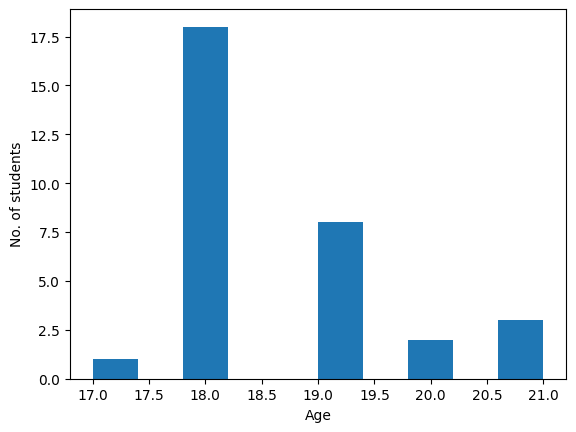

In [87]:
plt.hist((class_survey_df['How old are you?']))
plt.xlabel('Age') 
plt.ylabel('No. of students') 


([<matplotlib.patches.Wedge at 0x140c9de50>,
 [Text(1.0947031993394167, 0.10781885436251668, '0'),
  Text(-0.21459935421774104, 1.0788638084435536, '1'),
  Text(-0.6111272563215624, -0.9146165735327998, '2'),
  Text(0.6111272563215621, -0.9146165735328001, '3'),
  Text(1.0526343693054299, -0.31931314497990876, '4')],
 [Text(0.5971108360033182, 0.05881028419773636, '3%'),
  Text(-0.11705419320967692, 0.5884711682419382, '50%'),
  Text(-0.3333421398117613, -0.4988817673815271, '25%'),
  Text(0.3333421398117611, -0.49888176738152723, '12%'),
  Text(0.5741642014393252, -0.17417080635267748, '9%')])

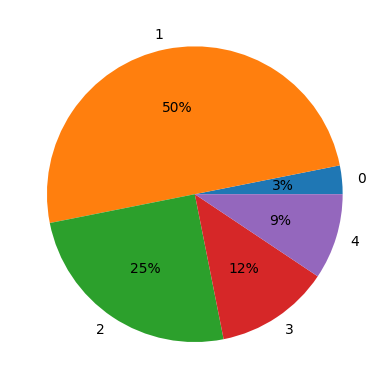

In [88]:
survey = class_survey_df.groupby('How many siblings do you have?').count()
survey.reset_index(inplace=True)
fig, ax = plt.subplots()
ax.pie(survey['country'],labels = survey['How many siblings do you have?'], autopct='%1.0f%%')


Text(0, 0.5, 'Programming Experience ')

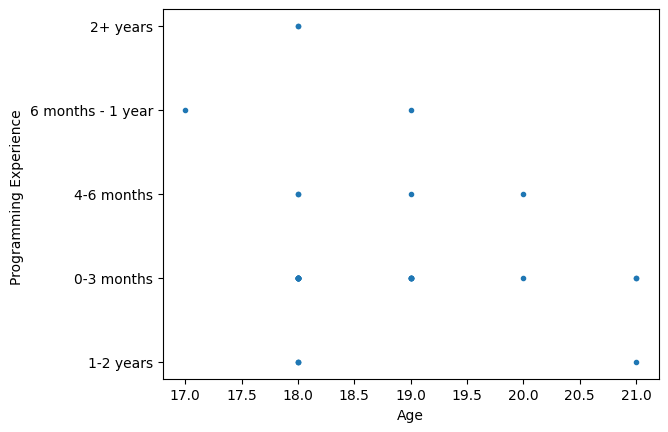

In [90]:
plt.plot(class_survey_df['How old are you?'], class_survey_df["How much experience do you have programming?"],'.')
plt.xlabel('Age')
plt.ylabel('Programming Experience ')

([<matplotlib.patches.Wedge at 0x140d74490>,
 [Text(-0.6111272563215622, 0.9146165735327999, 'No'),
  Text(0.6111272563215621, -0.9146165735328001, 'Yes')],
 [Text(-0.33334213981176114, 0.4988817673815272, '69%'),
  Text(0.3333421398117611, -0.49888176738152723, '31%')])

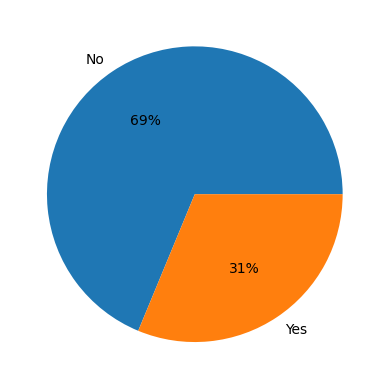

In [91]:
work = class_survey_df.groupby('Are you working while in school?').count()
work.reset_index(inplace=True)
fig, ax = plt.subplots()
ax.pie(work['country'],labels = work['Are you working while in school?'], autopct='%1.0f%%')

([<matplotlib.patches.Wedge at 0x1414dd790>,
 [Text(1.0897545402588844, 0.14978331677843057, 'All of the Above'),
  Text(0.7508084452685007, 0.8039195721672019, 'American'),
  Text(0.07506662398802001, 1.0974356482104275, 'German'),
  Text(-0.939861339184653, 0.5715423546037781, 'Italian'),
  Text(-0.368367634567315, -1.036486992587597, 'Japanese'),
  Text(0.9398613124288233, -0.5715423986018622, 'Mexican')],
 [Text(0.5944115674139369, 0.08169999097005304, '4%'),
  Text(0.40953187923736395, 0.43850158481847373, '17%'),
  Text(0.040945431266192725, 0.5986012626602332, '4%'),
  Text(-0.5126516395552653, 0.31175037523842436, '30%'),
  Text(-0.2009278006730809, -0.5653565414114164, '26%'),
  Text(0.5126516249611763, -0.3117503992373793, '17%')])

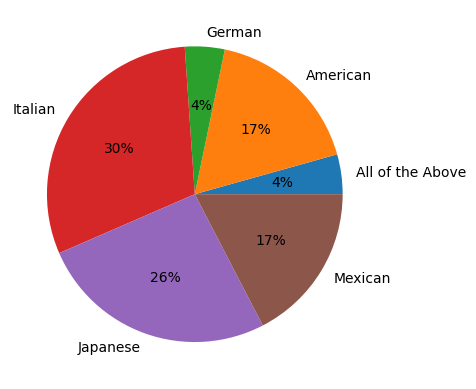

In [98]:
Food = class_survey_df.groupby('Favorite Cuisine').count()
Food.reset_index(inplace=True)
fig, ax = plt.subplots()
ax.pie(Food['country'],labels = Food['Favorite Cuisine'], autopct='%1.0f%%')